In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional

# === 路徑設定 ===
BROKER_DATA_DIR = Path("/Users/fang/Desktop/bs_report/parquet_twse")          # 存放券商買賣 parquet 的資料夾
WARRANT_LIST_PATH = Path("/Users/fang/StockAnalysis/data/warrant_list_dedup.csv")
OHLC_DIR = Path("/Users/fang/StockAnalysis/data/ohlc")                   # 內含 twse-YYYYMMDD.csv、tpex-YYYYMMDD.csv 等每日檔

# --- 權證對應 ---
def load_warrant_meta() -> pd.DataFrame:
    if not WARRANT_LIST_PATH.exists():
        return pd.DataFrame()
    df = pd.read_csv(WARRANT_LIST_PATH, dtype=str, encoding="utf-8-sig").fillna("")
    return df[df["權證代號"].str.len() > 4]

WARRANT_META = load_warrant_meta()

def resolve_underlying(code: str) -> tuple[str, str]:
    if WARRANT_META.empty or len(code.strip()) <= 4:
        return code, ""
    hit = WARRANT_META.loc[WARRANT_META["權證代號"].str.strip() == code]
    if hit.empty:
        return code, ""
    row = hit.iloc[0]
    return row["標的代號"], row.get("標的名稱", "")

# --- 資料載入 ---
def load_trades(code: str) -> pd.DataFrame:
    path = BROKER_DATA_DIR / f"{code}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"找不到 {path}")
    df = pd.read_parquet(path)
    df = df.rename(columns=str.strip)
    df["日期"] = pd.to_datetime(df["日期"], errors="coerce")
    df = df.dropna(subset=["日期"])
    return df

def load_price_series(code: str) -> pd.DataFrame:
    frames = []
    if not OHLC_DIR.exists():
        return pd.DataFrame(columns=["date", "close"])
    for csv_file in OHLC_DIR.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file, dtype=str)
        except Exception:
            continue
        if "證券代號" not in df.columns or "收盤價" not in df.columns:
            continue
        matches = df.loc[df["證券代號"].str.strip() == code]
        if matches.empty:
            continue
        # twse-YYYYMMDD or tpex-YYYYMMDD -> 取最後 8 碼
        parts = csv_file.stem.split("-")
        date_token = parts[-1] if parts else csv_file.stem
        try:
            trade_date = pd.to_datetime(date_token, format="%Y%m%d")
        except ValueError:
            continue
        price_raw = matches.iloc[0]["收盤價"].replace(",", "").strip()
        try:
            price = float(price_raw)
        except ValueError:
            price = np.nan
        frames.append((trade_date, price))
    if not frames:
        return pd.DataFrame(columns=["date", "close"])
    price_df = pd.DataFrame(frames, columns=["date", "close"]).dropna().sort_values("date")
    return price_df

# --- 聚合與集中度 ---
def aggregate_daily(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    per_broker = (
        df.groupby(["日期", "券商"], as_index=False)
          .agg(buy_shares=("買進股數", "sum"),
               sell_shares=("賣出股數", "sum"))
    )
    per_broker["net_shares"] = per_broker["buy_shares"] - per_broker["sell_shares"]

    daily = (
        per_broker.groupby("日期")[["buy_shares", "sell_shares", "net_shares"]]
                  .sum()
    )

    # 計算集中度指標
    hhi_rows = []
    for day, chunk in per_broker.groupby("日期"):
        positives = chunk.loc[chunk["net_shares"] > 0, "net_shares"]
        total = positives.sum()
        if total > 0:
            shares = positives / total
            hhi = np.square(shares).sum()
            top_share = shares.max()
        else:
            hhi, top_share = np.nan, np.nan
        hhi_rows.append((day, hhi, top_share))
    hhi_df = pd.DataFrame(hhi_rows, columns=["日期", "hhi", "top_share"]).set_index("日期")

    # 避免欄位重複
    daily = daily.drop(columns=[c for c in ["hhi", "top_share"] if c in daily.columns])
    daily = daily.join(hhi_df, how="left")

    return daily, per_broker

# --- 主視覺 ---
def plot_overview(code: str):
    is_warrant = len(code.strip()) > 4
    target_code, target_name = resolve_underlying(code)
    label = f"{code} (標的 {target_code})" if is_warrant else code

    trades = load_trades(code)
    daily, per_broker = aggregate_daily(trades)

    price_df = load_price_series(target_code if is_warrant else code)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    ax_vol, ax_conc = axes

    dates = daily.index
    ax_vol.bar(dates, daily["buy_shares"], color="#d62728", label="Buy Shares")
    ax_vol.bar(dates, -daily["sell_shares"], color="#2ca02c", label="Sell Shares")
    ax_vol.axhline(0, color="gray", linewidth=0.8)
    ax_vol.set_ylabel("Shares")
    ax_vol.legend(loc="upper left")

    if not price_df.empty:
        ax_price = ax_vol.twinx()
        ax_price.plot(price_df["date"], price_df["close"], color="#1f77b4", label="Close Price")
        ax_price.set_ylabel("Price")
        ax_price.legend(loc="upper right")

    ax_conc.plot(dates, daily["hhi"], label="HHI (net buy)", color="#9467bd")
    ax_conc.plot(dates, daily["top_share"], label="Top Share", color="#ff7f0e")
    ax_conc.set_ylim(0, 1)
    ax_conc.set_ylabel("Concentration")
    ax_conc.legend(loc="upper left")

    title = f"{label} – Buy/Sell & Concentration"
    if target_name:
        title += f" ({target_name})"
    fig.suptitle(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# --- 使用範例 ---
# plot_overview("2330")         # 上市股票
# plot_overview("03005P")       # 認購權證（會自動對應標的）


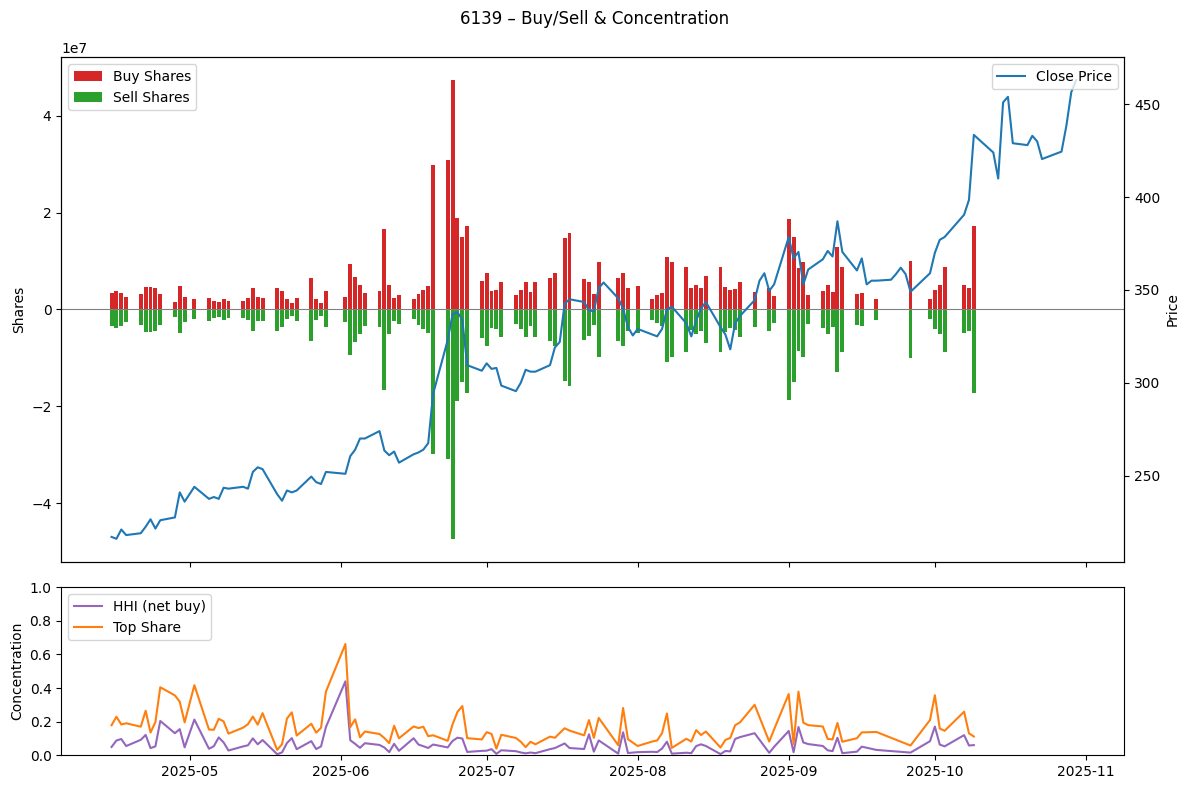

In [15]:
plot_overview("6139")